In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("COVID Analytics Pipeline") \
    .getOrCreate()

In [2]:
base_path = "data/"

files = {
    "full_grouped": base_path + "full_grouped.csv",
    "covid_clean": base_path + "covid_19_clean_complete.csv",
    "country_latest": base_path + "country_wise_latest.csv",
    "day_wise": base_path + "day_wise.csv",
    "usa_county": base_path + "usa_county_wise.csv",
    "worldometer": base_path + "worldometer_data.csv"
}

In [3]:
df_full_grouped = spark.read.csv(files["full_grouped"], header=True, inferSchema=True)

df_covid_clean = spark.read.csv(files["covid_clean"], header=True, inferSchema=True)

df_country_latest = spark.read.csv(files["country_latest"], header=True, inferSchema=True)

df_day_wise = spark.read.csv(files["day_wise"], header=True, inferSchema=True)

df_usa_county = spark.read.csv(files["usa_county"], header=True, inferSchema=True)

df_worldometer = spark.read.csv(files["worldometer"], header=True, inferSchema=True)

In [4]:
print("\n FULL GROUPED SCHEMA")
df_full_grouped.printSchema()


 FULL GROUPED SCHEMA
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [5]:
print("\n COVID CLEAN SCHEMA")
df_covid_clean.printSchema()


 COVID CLEAN SCHEMA
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [6]:
print("\n COUNTRY LATEST SCHEMA")
df_country_latest.printSchema()


 COUNTRY LATEST SCHEMA
root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: string (nullable = true)
 |-- Confirmed last week: integer (nullable = true)
 |-- 1 week change: integer (nullable = true)
 |-- 1 week % increase: double (nullable = true)
 |-- WHO Region: string (nullable = true)



In [7]:
print("\n DAY WISE SCHEMA")
df_day_wise.printSchema()


 DAY WISE SCHEMA
root
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: double (nullable = true)
 |-- No. of countries: integer (nullable = true)



In [8]:
print("\n USA COUNTY SCHEMA")
df_usa_county.printSchema()


 USA COUNTY SCHEMA
root
 |-- UID: integer (nullable = true)
 |-- iso2: string (nullable = true)
 |-- iso3: string (nullable = true)
 |-- code3: integer (nullable = true)
 |-- FIPS: double (nullable = true)
 |-- Admin2: string (nullable = true)
 |-- Province_State: string (nullable = true)
 |-- Country_Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long_: double (nullable = true)
 |-- Combined_Key: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)



In [9]:
print("\n WORLDOMETER SCHEMA")
df_worldometer.printSchema()


 WORLDOMETER SCHEMA
root
 |-- Country/Region: string (nullable = true)
 |-- Continent: string (nullable = true)
 |-- Population: integer (nullable = true)
 |-- TotalCases: integer (nullable = true)
 |-- NewCases: integer (nullable = true)
 |-- TotalDeaths: integer (nullable = true)
 |-- NewDeaths: integer (nullable = true)
 |-- TotalRecovered: integer (nullable = true)
 |-- NewRecovered: integer (nullable = true)
 |-- ActiveCases: integer (nullable = true)
 |-- Serious,Critical: integer (nullable = true)
 |-- Tot Cases/1M pop: integer (nullable = true)
 |-- Deaths/1M pop: double (nullable = true)
 |-- TotalTests: integer (nullable = true)
 |-- Tests/1M pop: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [10]:
print("\n ROW COUNTS")

print("Full Grouped:", df_full_grouped.count())
print("Covid Clean:", df_covid_clean.count())
print("Country Latest:", df_country_latest.count())
print("Day Wise:", df_day_wise.count())
print("USA County:", df_usa_county.count())
print("Worldometer:", df_worldometer.count())


 ROW COUNTS


Full Grouped: 35156
Covid Clean: 49068
Country Latest: 187
Day Wise: 188
USA County: 627920
Worldometer: 209


### Data Cleaning

#### Handle missing province/state values

In [11]:
from pyspark.sql.functions import col, when

In [12]:
(
    df_covid_clean
    .filter(col("Province/State").isNull())
    .show(5)
)

+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|Province/State|Country/Region|     Lat|     Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|          NULL|   Afghanistan|33.93911|67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|       Albania| 41.1533|  20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|       Algeria| 28.0339|   1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|       Andorra| 42.5063|   1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|        Angola|-11.2027|  17.8739|2020-01-22|        0|     0|        0|     0|              Africa|
+--------------+--------------+--------+---------+----------+---

In [13]:
null_count = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .count()
)

print("Total NULL values in Province/State:", null_count)

Total NULL values in Province/State: 34404


In [14]:
df_null_country = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .groupBy("Country/Region")
    .count()
    .orderBy(col("count").desc())
)

df_null_country.show()

+--------------+-----+
|Country/Region|count|
+--------------+-----+
|          Chad|  188|
|      Paraguay|  188|
|        Russia|  188|
|         Yemen|  188|
|       Senegal|  188|
|    Cabo Verde|  188|
|        Sweden|  188|
|        Guyana|  188|
|       Eritrea|  188|
|   Philippines|  188|
|         Burma|  188|
|      Djibouti|  188|
|      Malaysia|  188|
|     Singapore|  188|
|          Fiji|  188|
|        Turkey|  188|
|        Malawi|  188|
|Western Sahara|  188|
|          Iraq|  188|
|       Germany|  188|
+--------------+-----+
only showing top 20 rows


In [15]:
df_covid_clean = (
    df_covid_clean
    .fillna({"Province/State": "Unknown"})
)

In [16]:
df_covid_clean.show()

+--------------------+-------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|      Province/State|     Country/Region|      Lat|      Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------------+-------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|             Unknown|        Afghanistan| 33.93911| 67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|             Unknown|            Albania|  41.1533|   20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|             Unknown|            Algeria|  28.0339|    1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|             Unknown|            Andorra|  42.5063|    1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|             Unknown|             Angola| -11.2027|   17.8739|2020-01-22|        0|     0

In [17]:
remaining_nulls = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .count()
)

print("Remaining NULL values:", remaining_nulls)

Remaining NULL values: 0


#### Standardize country names

In [18]:
(
    df_full_grouped
    .select("Country/Region")
    .distinct()
    .show(100, truncate=False)
)

+------------------------+
|Country/Region          |
+------------------------+
|Chad                    |
|Paraguay                |
|Russia                  |
|Yemen                   |
|Senegal                 |
|Cabo Verde              |
|Sweden                  |
|Guyana                  |
|Burma                   |
|Eritrea                 |
|Philippines             |
|Djibouti                |
|Malaysia                |
|Singapore               |
|Fiji                    |
|Turkey                  |
|Malawi                  |
|Western Sahara          |
|Iraq                    |
|Germany                 |
|Comoros                 |
|Afghanistan             |
|Cambodia                |
|Jordan                  |
|Maldives                |
|Rwanda                  |
|Sudan                   |
|France                  |
|Greece                  |
|Kosovo                  |
|Sri Lanka               |
|Dominica                |
|Algeria                 |
|Equatorial Guinea       |
|

In [19]:
# Defining a function to standardize country names
def standardize_countries(df):
    return df.withColumn(
        "Country/Region",
        when(col("Country/Region") == "US", "USA")
        .when(col("Country/Region") == "S. Korea", "South Korea")
        .otherwise(col("Country/Region"))
    )

In [20]:
# Applying the standardization to the relevant DataFrames
df_full_grouped = standardize_countries(df_full_grouped)
df_country_latest = standardize_countries(df_country_latest)
df_worldometer = standardize_countries(df_worldometer)

In [21]:
print("Verification in full_grouped (Should be USA and South Korea):")
df_full_grouped.filter(col("Country/Region").isin("USA", "US", "South Korea", "S. Korea")) \
    .select("Country/Region").distinct().show()

Verification in full_grouped (Should be USA and South Korea):
+--------------+
|Country/Region|
+--------------+
|           USA|
|   South Korea|
+--------------+



In [22]:
print("Verification in worldometer (Should be USA and South Korea):")
df_worldometer.filter(col("Country/Region").isin("USA", "US", "South Korea", "S. Korea")) \
    .select("Country/Region").distinct().show()

Verification in worldometer (Should be USA and South Korea):
+--------------+
|Country/Region|
+--------------+
|           USA|
|   South Korea|
+--------------+



#### Remove duplicate rows

In [23]:
# Count rows before removing duplicates to see if any exist
count_before = df_full_grouped.count()
print(f"Rows before dropping duplicates: {count_before}")

# Drop duplicates based on 'Country/Region' and 'Date'
df_full_grouped = df_full_grouped.dropDuplicates(["Country/Region", "Date"])

# Count rows after removing duplicates
count_after = df_full_grouped.count()
print(f"Rows after dropping duplicates: {count_after}")

# Print how many duplicates were found and removed
duplicates_removed = count_before - count_after
print(f"Total duplicates removed: {duplicates_removed}")

Rows before dropping duplicates: 35156
Rows after dropping duplicates: 35156
Total duplicates removed: 0


In [24]:
import matplotlib.pyplot as plt

#### Top 10 Countries by Total Confirmed Cases

In [25]:
# Getting Top 10 Countries by Total Confirmed Cases
top_10_confirmed = (df_country_latest
    .select("Country/Region", "Confirmed")
    .orderBy(col("Confirmed").desc())
    .limit(10))

In [26]:
print("Top 10 Countries by Total Confirmed Cases:")
top_10_confirmed.show()

Top 10 Countries by Total Confirmed Cases:
+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|           USA|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



In [27]:
# Converting the PySpark DataFrame to a Pandas DataFrame for plotting
top_10_pd = top_10_confirmed.toPandas()

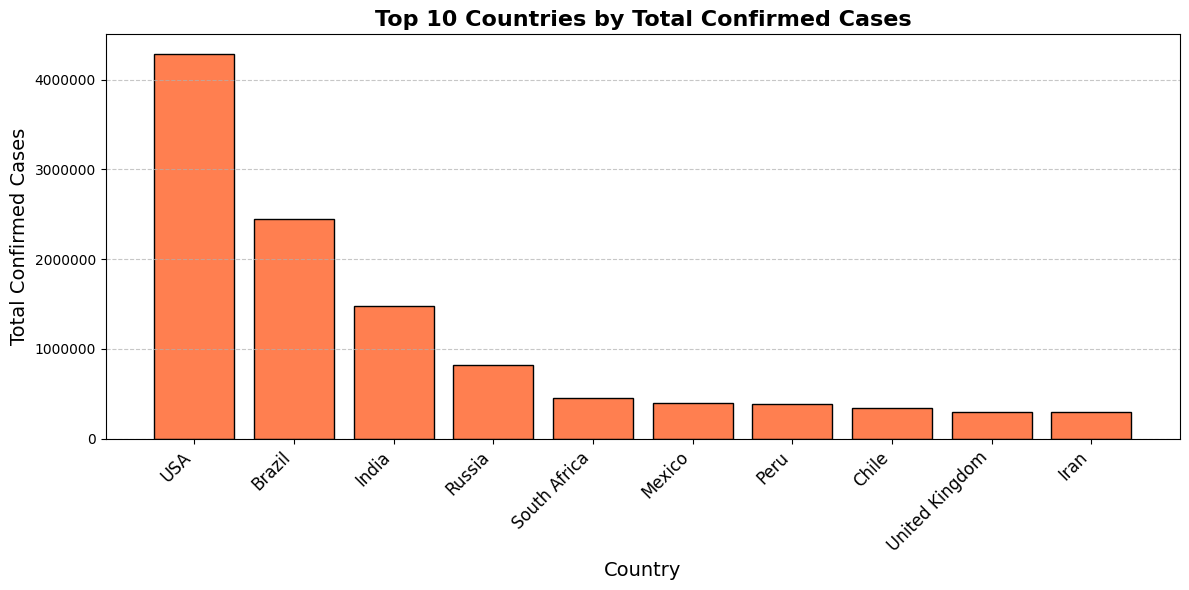

In [28]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_pd["Country/Region"], top_10_pd["Confirmed"], color='coral', edgecolor='black')

plt.title("Top 10 Countries by Total Confirmed Cases", fontsize=16, fontweight='bold')
plt.xlabel("Country", fontsize=14)
plt.ylabel("Total Confirmed Cases", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Top 10 Countries by Death Rate

In [29]:
# Getting Top 10 Countries by Death Rate (Deaths / 100 Cases)
top_10_death_rate = (df_country_latest
    .select("Country/Region", "Deaths / 100 Cases")
    .orderBy(col("Deaths / 100 Cases").desc())
    .limit(10))

In [30]:
print("Top 10 Countries by Death Rate (Deaths / 100 Cases):")
top_10_death_rate.show()

Top 10 Countries by Death Rate (Deaths / 100 Cases):
+--------------+------------------+
|Country/Region|Deaths / 100 Cases|
+--------------+------------------+
|         Yemen|             28.56|
|United Kingdom|             15.19|
|       Belgium|             14.79|
|         Italy|             14.26|
|        France|             13.71|
|       Hungary|              13.4|
|   Netherlands|             11.53|
|        Mexico|             11.13|
|         Spain|             10.44|
|Western Sahara|              10.0|
+--------------+------------------+



In [31]:
top_10_death_pd = top_10_death_rate.toPandas()

In [32]:
top_10_death_pd = top_10_death_pd.sort_values(by="Deaths / 100 Cases", ascending=True)

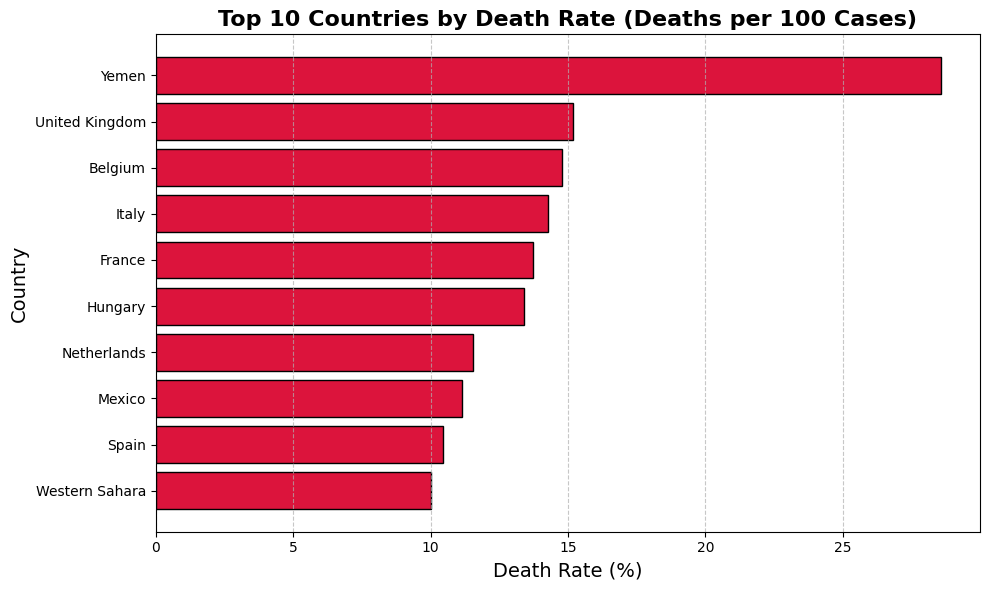

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_death_pd["Country/Region"], top_10_death_pd["Deaths / 100 Cases"], color='crimson', edgecolor='black')

plt.title("Top 10 Countries by Death Rate (Deaths per 100 Cases)", fontsize=16, fontweight='bold')
plt.xlabel("Death Rate (%)", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### WHO Region wise total cases

In [34]:
from pyspark.sql.functions import sum as _sum, max as _max
import pandas as pd

In [35]:
# Finding the latest date in the dataset
latest_date = df_full_grouped.select(_max("Date")).collect()[0][0]
print(f"Aggregating data for the latest date: {latest_date}")

Aggregating data for the latest date: 2020-07-27


In [36]:
# Filter for the latest date, then group by WHO Region and aggregate
who_region_totals = (df_full_grouped
    .filter(col("Date") == latest_date)
    .groupBy("WHO Region")
    .agg(
        _sum("Confirmed").alias("Total Confirmed"),
        _sum("Deaths").alias("Total Deaths"),
        _sum("Recovered").alias("Total Recovered")
    )
    .orderBy(col("Total Confirmed").desc()))

In [37]:
# Show the output table
print("WHO Region-wise Total Cases:")
who_region_totals.show()

WHO Region-wise Total Cases:
+--------------------+---------------+------------+---------------+
|          WHO Region|Total Confirmed|Total Deaths|Total Recovered|
+--------------------+---------------+------------+---------------+
|            Americas|        8839286|      342732|        4468616|
|              Europe|        3299523|      211144|        1993723|
|     South-East Asia|        1835297|       41349|        1156933|
|Eastern Mediterra...|        1490744|       38339|        1201400|
|              Africa|         723207|       12223|         440645|
|     Western Pacific|         292428|        8249|         206770|
+--------------------+---------------+------------+---------------+



In [38]:
who_pd = who_region_totals.toPandas()

In [39]:
# Ensuring WHO Region is the index for easier stacked bar plotting
who_pd.set_index("WHO Region", inplace=True)

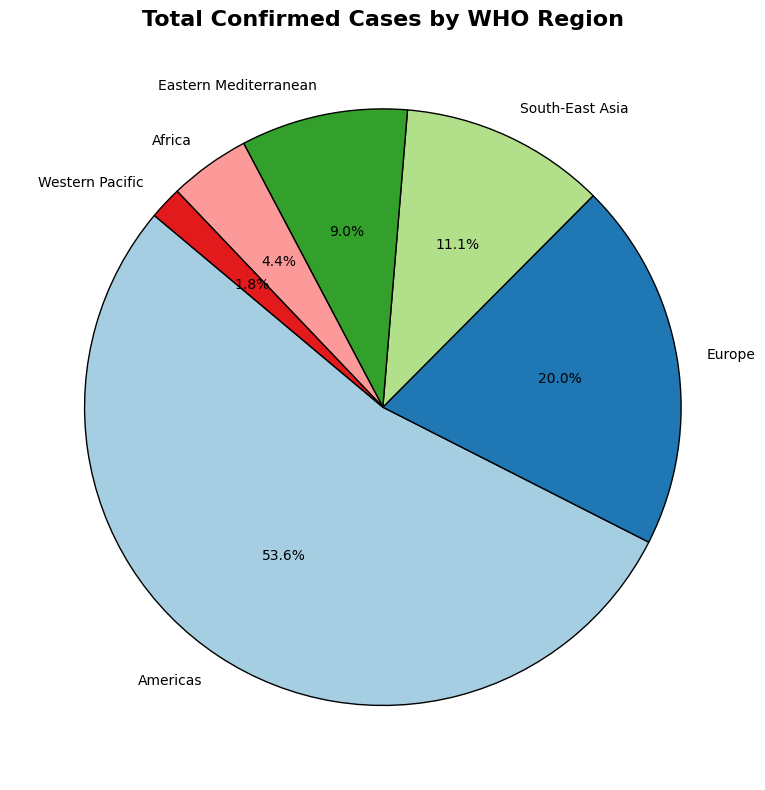

In [40]:
plt.figure(figsize=(8, 8))
plt.pie(who_pd["Total Confirmed"], labels=who_pd.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Paired.colors, wedgeprops={'edgecolor': 'black'})
plt.title("Total Confirmed Cases by WHO Region", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Active = Confirmed - (Deaths + Recovered)
who_pd["Active Cases"] = who_pd["Total Confirmed"] - (who_pd["Total Deaths"] + who_pd["Total Recovered"])

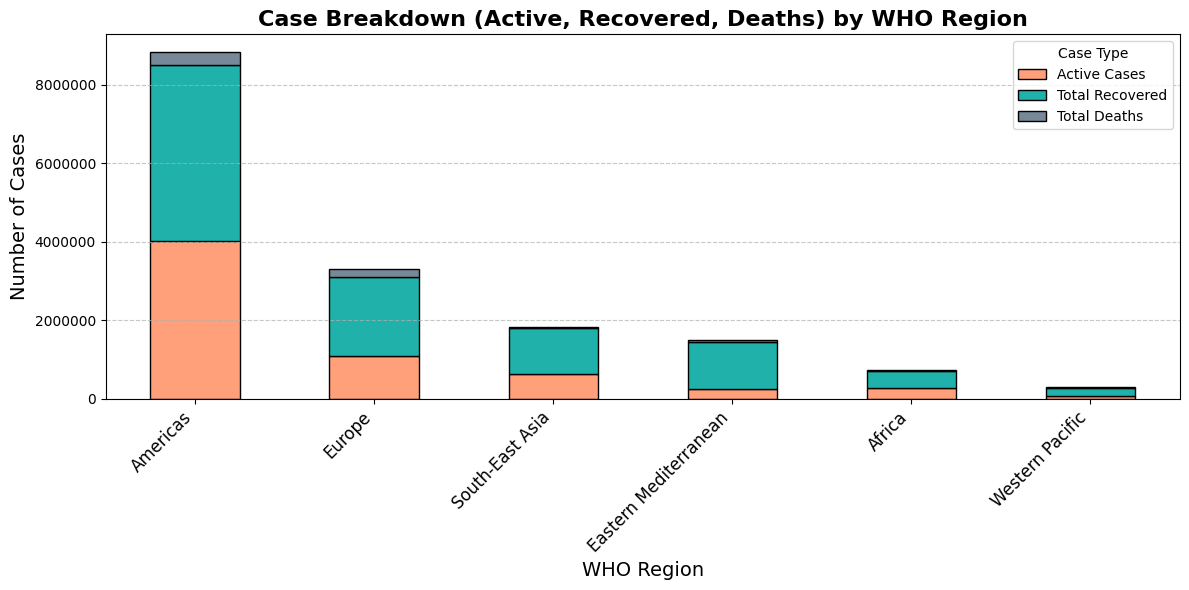

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))
who_pd[["Active Cases", "Total Recovered", "Total Deaths"]].plot(
    kind='bar', stacked=True, ax=ax, color=['#FFA07A', '#20B2AA', '#778899'], edgecolor='black'
)

plt.title("Case Breakdown (Active, Recovered, Deaths) by WHO Region", fontsize=16, fontweight='bold')
plt.xlabel("WHO Region", fontsize=14)
plt.ylabel("Number of Cases", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Disabled scientific notation
plt.legend(title="Case Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Time series Analysis

#### Daily Global New Cases Trend

In [43]:
import matplotlib.dates as mdates

In [44]:
# Selecting relevant columns and sort by Date
daily_new_cases = (df_day_wise
    .select("Date", "New cases")
    .orderBy(col("Date").asc()))

In [45]:
# Showing a sample of the output table
print("Daily Global New Cases:")
daily_new_cases.show(5)

Daily Global New Cases:
+----------+---------+
|      Date|New cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
+----------+---------+
only showing top 5 rows


In [46]:
daily_cases_pd = daily_new_cases.toPandas()

In [47]:
daily_cases_pd["Date"] = pd.to_datetime(daily_cases_pd["Date"])

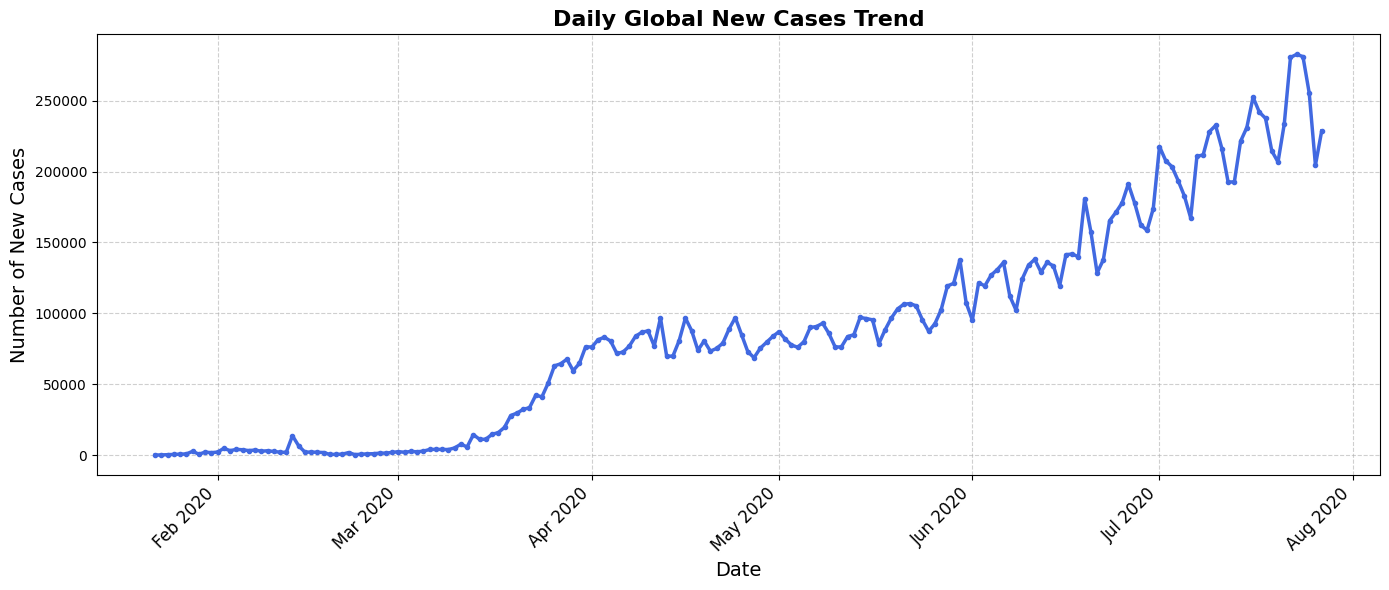

In [48]:
# Creating the plot
plt.figure(figsize=(14, 6))
plt.plot(daily_cases_pd["Date"], daily_cases_pd["New cases"], color='royalblue', linewidth=2.5, marker='o', markersize=3)

# Formatting the chart
plt.title("Daily Global New Cases Trend", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of New Cases", fontsize=14)

# Formatting the x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation on Y-axis

plt.tight_layout()
plt.show()

####  Daily Global Death Growth Trend

In [49]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, round

In [50]:
# Defining the Window Specification (Ordered chronologically by Date)
windowSpec = Window.orderBy("Date")

In [51]:
# Using lag() to create a column for the previous day's deaths
daily_death_growth = df_day_wise.withColumn(
    "previous_day_deaths", lag("New deaths", 1).over(windowSpec)
)

In [52]:
# Calculating the daily death growth percentage
daily_death_growth = daily_death_growth.withColumn(
    "death_growth_percentage",
    when(col("previous_day_deaths").isNull() | (col("previous_day_deaths") == 0), 0)
    .otherwise(round((col("New deaths") / col("previous_day_deaths")) * 100, 2))
)

In [53]:
# Showing a sample of the results
print("Daily Global Death Growth Trend:")
daily_death_growth.select("Date", "New deaths", "previous_day_deaths", "death_growth_percentage").show(10)

Daily Global Death Growth Trend:
+----------+----------+-------------------+-----------------------+
|      Date|New deaths|previous_day_deaths|death_growth_percentage|
+----------+----------+-------------------+-----------------------+
|2020-01-22|         0|               NULL|                    0.0|
|2020-01-23|         1|                  0|                    0.0|
|2020-01-24|         8|                  1|                  800.0|
|2020-01-25|        16|                  8|                  200.0|
|2020-01-26|        14|                 16|                   87.5|
|2020-01-27|        26|                 14|                 185.71|
|2020-01-28|        49|                 26|                 188.46|
|2020-01-29|         2|                 49|                   4.08|
|2020-01-30|        38|                  2|                 1900.0|
|2020-01-31|        42|                 38|                 110.53|
+----------+----------+-------------------+-----------------------+
only showing to

In [54]:
# Visualization
death_growth_pd = daily_death_growth.select("Date", "death_growth_percentage").toPandas()

In [55]:
death_growth_pd["Date"] = pd.to_datetime(death_growth_pd["Date"])

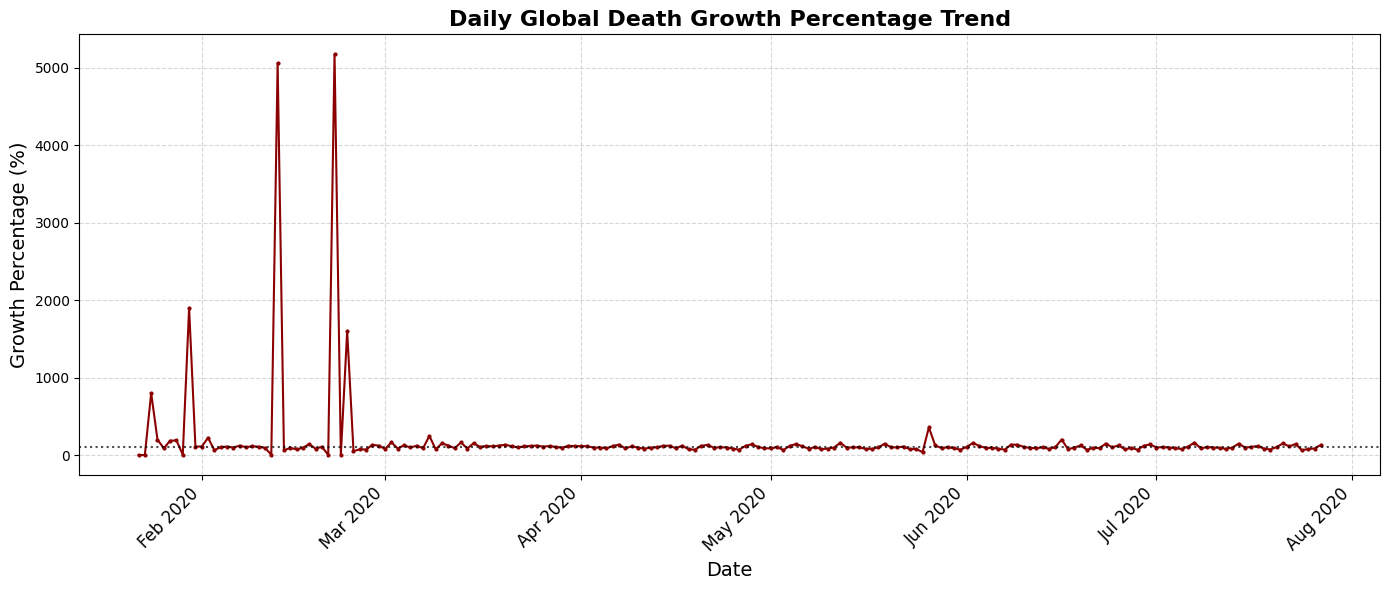

In [56]:
# Creating the plot
plt.figure(figsize=(14, 6))
plt.plot(death_growth_pd["Date"], death_growth_pd["death_growth_percentage"], 
         color='darkred', linewidth=1.5, marker='.', markersize=4)

# Formatting the chart
plt.title("Daily Global Death Growth Percentage Trend", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Growth Percentage (%)", fontsize=14)

# Formatting the X-axis for readable dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right', fontsize=12)

# Adding a grid and bounding limits
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.axhline(y=100, color='black', linestyle=':', alpha=0.7) # Add a reference line for 100%

plt.tight_layout()
plt.show()

#### Monthly COVID Case Growth

In [57]:
from pyspark.sql.functions import month, to_date, sum as _sum
import calendar

In [58]:
# Converting Date string to DateType, extract the Month, and calculate the sum of New cases
monthly_growth = (df_full_grouped
    .withColumn("Date_Parsed", to_date(col("Date"), "yyyy-MM-dd")) # Ensure proper date format
    .withColumn("Month", month(col("Date_Parsed")))
    .groupBy("Month")
    .agg(_sum("New cases").alias("Total Confirmed Cases Growth"))
    .orderBy(col("Month").asc()))

In [59]:
# Showing the output table
print("Monthly COVID Case Growth:")
monthly_growth.show()

Monthly COVID Case Growth:
+-----+----------------------------+
|Month|Total Confirmed Cases Growth|
+-----+----------------------------+
|    1|                        9372|
|    2|                       75379|
|    3|                      786064|
|    4|                     2412383|
|    5|                     2921042|
|    6|                     4265801|
|    7|                     6030911|
+-----+----------------------------+



In [60]:
monthly_growth_pd = monthly_growth.toPandas()

In [61]:
# Converting integer month (1, 2, 3...) to short month names (Jan, Feb, Mar...) for a better looking chart
monthly_growth_pd["Month Name"] = monthly_growth_pd["Month"].apply(lambda x: calendar.month_abbr[x])

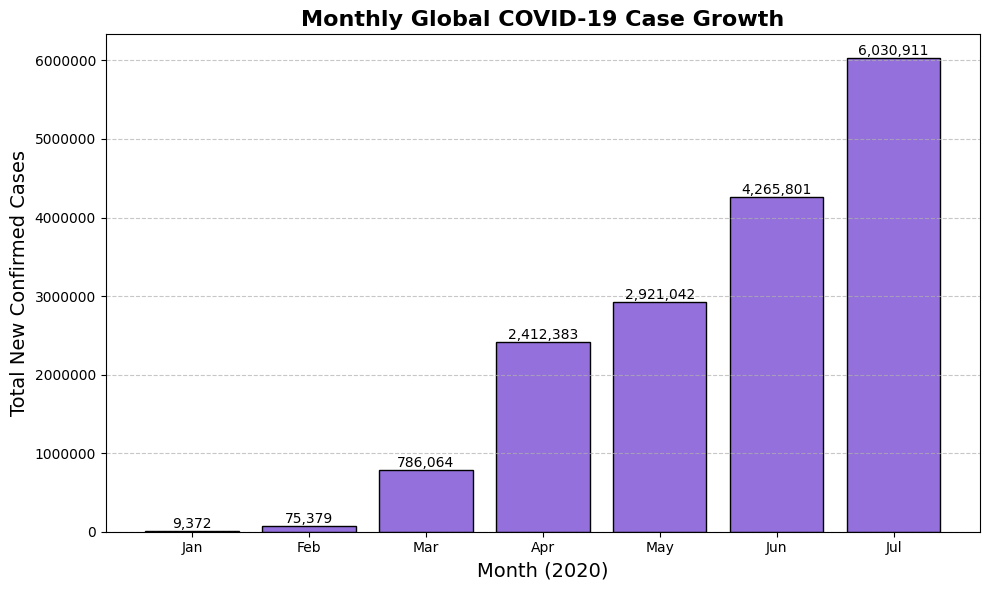

In [62]:
# Creating the plot
plt.figure(figsize=(10, 6))
plt.bar(monthly_growth_pd["Month Name"], monthly_growth_pd["Total Confirmed Cases Growth"], 
        color='mediumpurple', edgecolor='black')

# Formatting the chart
plt.title("Monthly Global COVID-19 Case Growth", fontsize=16, fontweight='bold')
plt.xlabel("Month (2020)", fontsize=14)
plt.ylabel("Total New Confirmed Cases", fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding data labels on top of the bars for clarity
for index, value in enumerate(monthly_growth_pd["Total Confirmed Cases Growth"]):
    plt.text(index, value, f"{value:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Window Function Tasks

#### Top 5 Most Affected Countries Per WHO Region

In [63]:
from pyspark.sql.functions import dense_rank
import seaborn as sns

In [64]:
# Defining the Window Specification
windowSpec = Window.partitionBy("WHO Region").orderBy(col("Confirmed").desc())

In [65]:
# Appling dense_rank() over the window
ranked_countries = df_country_latest.withColumn("Rank", dense_rank().over(windowSpec))

In [66]:
# Filtering for only the Top 5 countries in each region
top_5_per_region = ranked_countries.filter(col("Rank") <= 5)

In [67]:
# 4. Show the output table
print("Top 5 Most Affected Countries Per WHO Region:")
top_5_per_region.select("WHO Region", "Rank", "Country/Region", "Confirmed").show(30, truncate=False)

Top 5 Most Affected Countries Per WHO Region:
+---------------------+----+--------------+---------+
|WHO Region           |Rank|Country/Region|Confirmed|
+---------------------+----+--------------+---------+
|Africa               |1   |South Africa  |452529   |
|Africa               |2   |Nigeria       |41180    |
|Africa               |3   |Ghana         |33624    |
|Africa               |4   |Algeria       |27973    |
|Africa               |5   |Kenya         |17975    |
|Americas             |1   |USA           |4290259  |
|Americas             |2   |Brazil        |2442375  |
|Americas             |3   |Mexico        |395489   |
|Americas             |4   |Peru          |389717   |
|Americas             |5   |Chile         |347923   |
|Eastern Mediterranean|1   |Iran          |293606   |
|Eastern Mediterranean|2   |Pakistan      |274289   |
|Eastern Mediterranean|3   |Saudi Arabia  |268934   |
|Eastern Mediterranean|4   |Iraq          |112585   |
|Eastern Mediterranean|5   |Qatar   

In [68]:
top_5_pd = top_5_per_region.toPandas()

In [69]:
top_5_pd = top_5_pd.sort_values(by=["Rank", "WHO Region"])

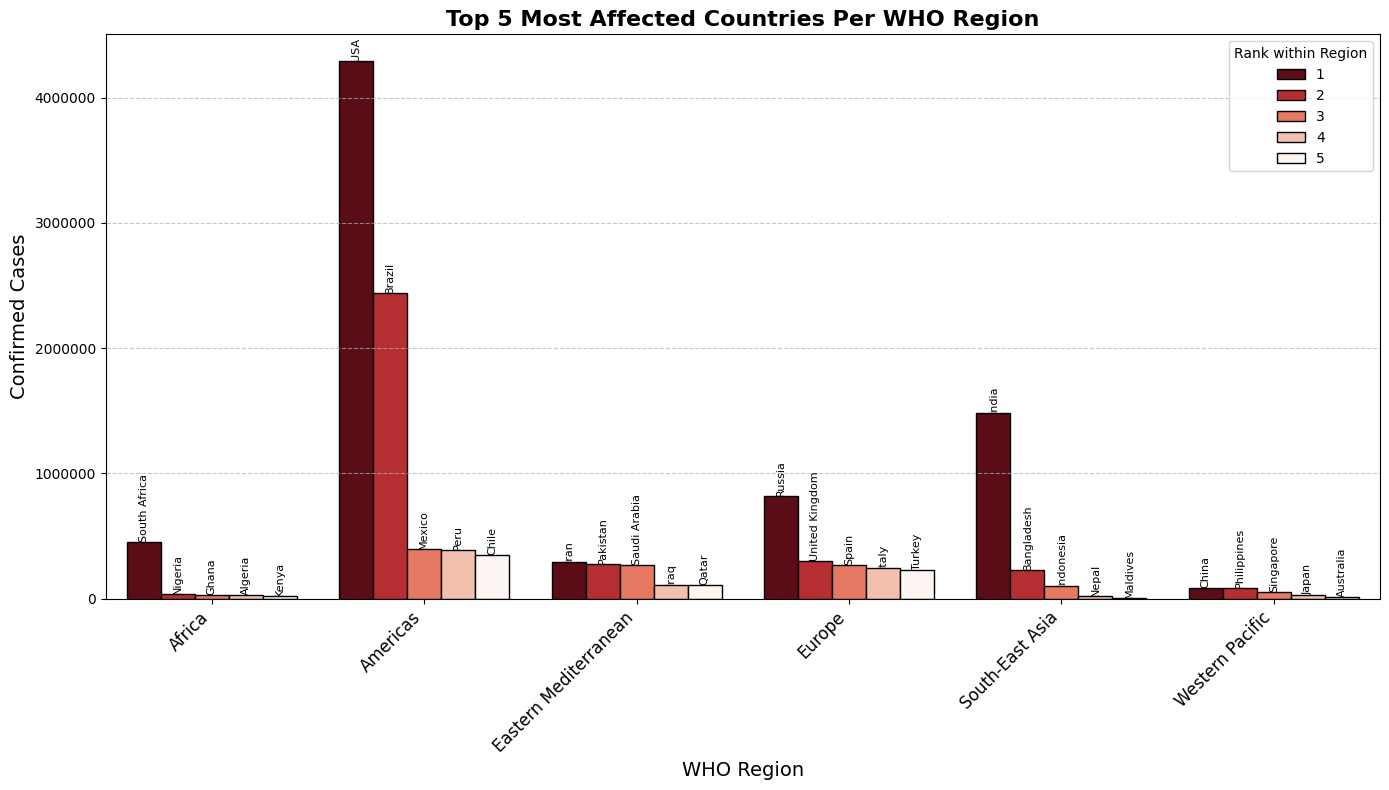

In [70]:
# Plotting
plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_5_pd, 
    x="WHO Region", 
    y="Confirmed", 
    hue="Rank", 
    palette="Reds_r", # Reversing a Red palette so Rank 1 is darkest
    edgecolor='black'
)

# Formatting the chart
plt.title("Top 5 Most Affected Countries Per WHO Region", fontsize=16, fontweight='bold')
plt.xlabel("WHO Region", fontsize=14)
plt.ylabel("Confirmed Cases", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') 
plt.legend(title="Rank within Region", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax = plt.gca()
for p, country in zip(ax.patches, top_5_pd['Country/Region']):
    # Check if patch is valid
    if p.get_height() > 0:
        ax.text(
            p.get_x() + p.get_width() / 2., 
            p.get_height(), 
            country, 
            fontsize=8, 
            ha='center', 
            va='bottom', 
            rotation=90
        )

plt.tight_layout()
plt.show()

#### Country-wise Daily Case Increase

In [71]:
windowSpec = Window.partitionBy("Country/Region").orderBy(col("Date").asc())

In [72]:
# Using lag() to pull the previous day's confirmed cases into the current row
country_daily_increase = df_full_grouped.withColumn(
    "yesterday_confirmed", lag("Confirmed", 1).over(windowSpec)
)

In [73]:
# Calculate the increase: today_confirmed - yesterday_confirmed
# If yesterday_confirmed is null (i.e., the very first day recorded), the increase is just the day's Confirmed cases.
country_daily_increase = country_daily_increase.withColumn(
    "calculated_daily_increase",
    when(col("yesterday_confirmed").isNull(), col("Confirmed"))
    .otherwise(col("Confirmed") - col("yesterday_confirmed"))
)

In [74]:
# Showing a sample of the output table (e.g., showing India's timeline)
print("Country-wise Daily Case Increase (Sample: India):")
country_daily_increase.filter(col("Country/Region") == "India") \
    .select("Date", "Country/Region", "Confirmed", "yesterday_confirmed", "calculated_daily_increase") \
    .show(10)

Country-wise Daily Case Increase (Sample: India):
+----------+--------------+---------+-------------------+-------------------------+
|      Date|Country/Region|Confirmed|yesterday_confirmed|calculated_daily_increase|
+----------+--------------+---------+-------------------+-------------------------+
|2020-01-22|         India|        0|               NULL|                        0|
|2020-01-23|         India|        0|                  0|                        0|
|2020-01-24|         India|        0|                  0|                        0|
|2020-01-25|         India|        0|                  0|                        0|
|2020-01-26|         India|        0|                  0|                        0|
|2020-01-27|         India|        0|                  0|                        0|
|2020-01-28|         India|        0|                  0|                        0|
|2020-01-29|         India|        0|                  0|                        0|
|2020-01-30|         India

In [75]:
# 5. Visualization: Country Trend Chart
countries_to_plot = ["USA", "Brazil", "India", "Russia", "South Africa"]
trend_df = country_daily_increase.filter(col("Country/Region").isin(countries_to_plot))

In [76]:
trend_pd = trend_df.select("Date", "Country/Region", "calculated_daily_increase").toPandas()

In [77]:
# Convert dates to proper datetime objects for formatting
trend_pd["Date"] = pd.to_datetime(trend_pd["Date"])

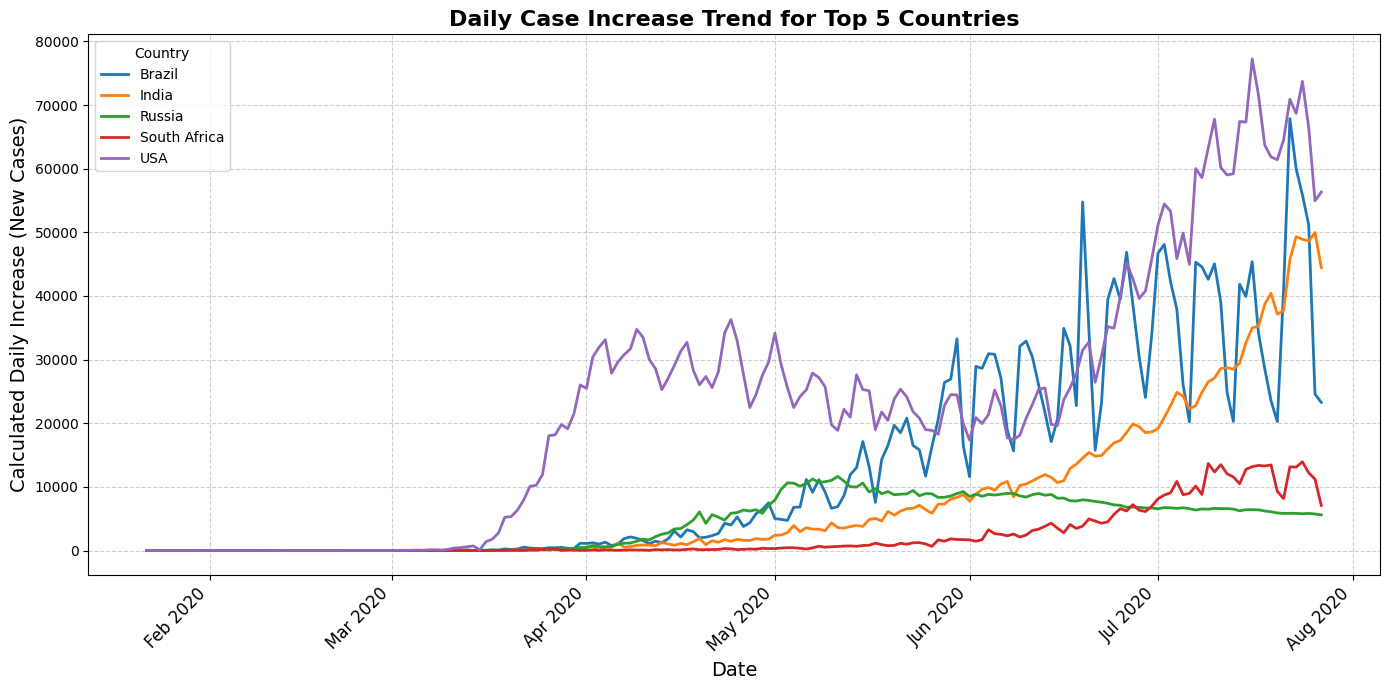

In [78]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=trend_pd, 
    x="Date", 
    y="calculated_daily_increase", 
    hue="Country/Region", 
    linewidth=2
)

# Formatting the chart
plt.title("Daily Case Increase Trend for Top 5 Countries", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Calculated Daily Increase (New Cases)", fontsize=14)

# Format the X-axis to show months beautifully
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Country", loc="upper left")
plt.grid(axis='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Join Operations

#### Compare Latest Dataset Sources

In [79]:
from pyspark.sql.functions import abs as _abs

In [80]:
cw = df_country_latest.alias("cw")
wm = df_worldometer.alias("wm")

In [81]:
# Performing an Inner Join on 'Country/Region'
comparison_df = cw.join(wm, col("cw.`Country/Region`") == col("wm.`Country/Region`"), "inner")

In [82]:
# Calculating the absolute differences between the two sources
comparison_df = comparison_df.withColumn(
    "Confirmed_Diff", _abs(col("cw.Confirmed") - col("wm.TotalCases"))
).withColumn(
    "Death_Diff", _abs(col("cw.Deaths") - col("wm.TotalDeaths"))
).withColumn(
    "Recovery_Diff", _abs(col("cw.Recovered") - col("wm.TotalRecovered"))
)

In [83]:
# Filtering and sorting to find countries with the largest mismatches in Confirmed Cases
large_mismatches = (comparison_df
    .select(
        col("cw.`Country/Region`").alias("Country"),
        col("cw.Confirmed").alias("CW_Confirmed"),
        col("wm.TotalCases").alias("WM_TotalCases"),
        "Confirmed_Diff",
        "Death_Diff",
        "Recovery_Diff"
    )
    .orderBy(col("Confirmed_Diff").desc())
)

In [84]:
# Show the output table (Top 10 largest mismatches)
print("Top 10 Countries with Largest Mismatches in Confirmed Cases Between Sources:")
large_mismatches.show(10, truncate=False)

Top 10 Countries with Largest Mismatches in Confirmed Cases Between Sources:
+------------+------------+-------------+--------------+----------+-------------+
|Country     |CW_Confirmed|WM_TotalCases|Confirmed_Diff|Death_Diff|Recovery_Diff|
+------------+------------+-------------+--------------+----------+-------------+
|USA         |4290259     |5032179      |741920        |14793     |1250864      |
|India       |1480073     |2025409      |545336        |8230      |426218       |
|Brazil      |2442375     |2917562      |475187        |11026     |201019       |
|Colombia    |257101      |357710       |100609        |3162      |61194        |
|South Africa|452529      |538184       |85655         |2537      |112391       |
|Spain       |272421      |354530       |82109         |68        |NULL         |
|Mexico      |395489      |462690       |67201         |6495      |5038         |
|Peru        |389717      |455409       |65692         |2006      |37790        |
|Argentina   |167416 

In [85]:
# Convert top 20 to Pandas for plotting
mismatch_pd = large_mismatches.limit(20).toPandas()

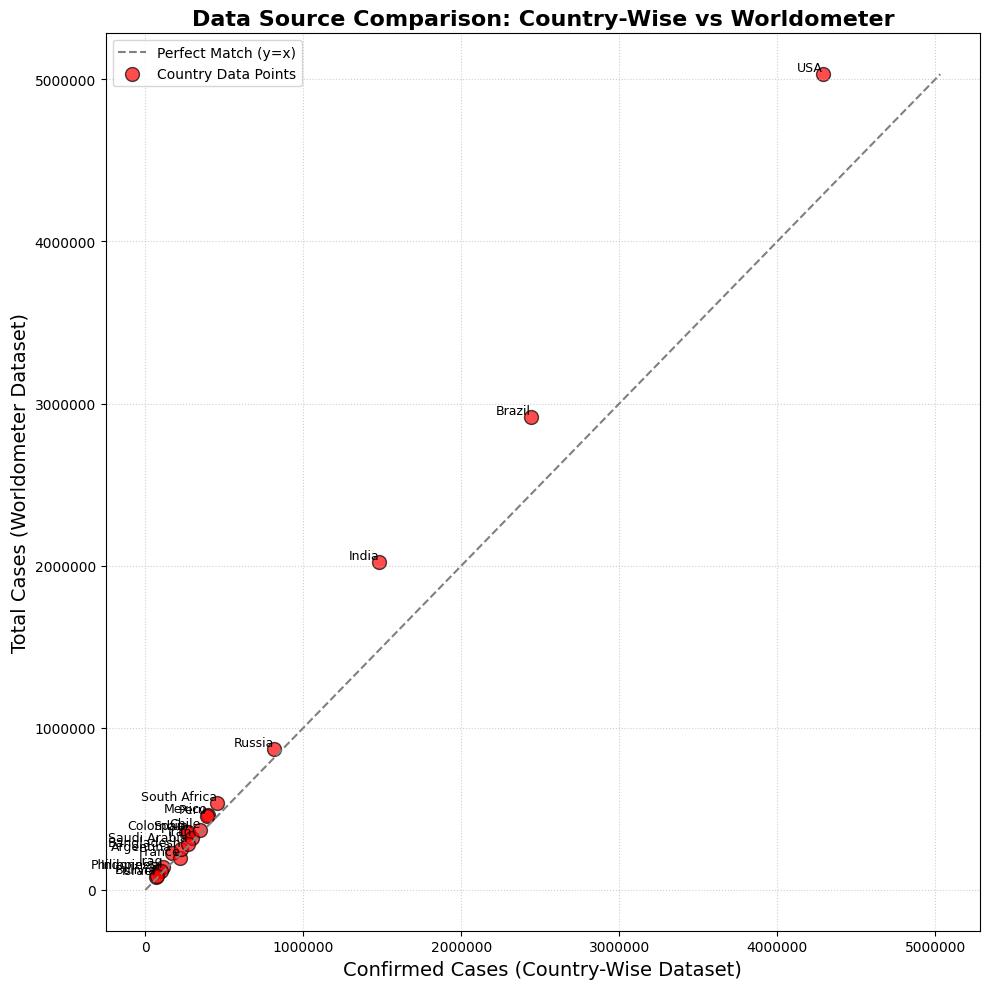

In [86]:
plt.figure(figsize=(10, 10))
max_val = max(mismatch_pd["CW_Confirmed"].max(), mismatch_pd["WM_TotalCases"].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='Perfect Match (y=x)')

# Scatter plot of the actual data points
plt.scatter(
    mismatch_pd["CW_Confirmed"], 
    mismatch_pd["WM_TotalCases"], 
    color='red', 
    edgecolor='black', 
    s=100, 
    alpha=0.7, 
    label='Country Data Points'
)

# Formatting the chart
plt.title("Data Source Comparison: Country-Wise vs Worldometer", fontsize=16, fontweight='bold')
plt.xlabel("Confirmed Cases (Country-Wise Dataset)", fontsize=14)
plt.ylabel("Total Cases (Worldometer Dataset)", fontsize=14)
plt.ticklabel_format(style='plain', axis='both') # Disable scientific notation
plt.grid(True, linestyle=':', alpha=0.6)

# Annotate the points with the country names
for i, row in mismatch_pd.iterrows():
    plt.text(row["CW_Confirmed"], row["WM_TotalCases"], row["Country"], fontsize=9, ha='right', va='bottom')

plt.legend()
plt.tight_layout()
plt.show()

#### Population vs Total Cases

In [87]:
from pyspark.sql.functions import round as _round

In [88]:
# 1. Calculate the infection rate: (TotalCases / Population) * 100
infection_df = df_worldometer.withColumn(
    "infection_rate",
    when(col("Population").isNull() | (col("Population") == 0), 0)
    .otherwise(_round((col("TotalCases") / col("Population")) * 100, 2))
)

In [89]:
# Finding the top 15 countries with the highest infection rate
top_infection_rates = (infection_df
    .select("Country/Region", "Population", "TotalCases", "infection_rate")
    .orderBy(col("infection_rate").desc())
    .limit(15))

In [90]:
# Showing the output table
print("Top 15 Countries by Infection Rate (% of Population):")
top_infection_rates.show(15, truncate=False)

Top 15 Countries by Infection Rate (% of Population):
+--------------+----------+----------+--------------+
|Country/Region|Population|TotalCases|infection_rate|
+--------------+----------+----------+--------------+
|Qatar         |2807805   |112092    |3.99          |
|French Guiana |299385    |8127      |2.71          |
|Bahrain       |1706669   |42889     |2.51          |
|San Marino    |33938     |699       |2.06          |
|Chile         |19132514  |366671    |1.92          |
|Panama        |4321282   |71418     |1.65          |
|Kuwait        |4276658   |70045     |1.64          |
|Oman          |5118446   |80713     |1.58          |
|USA           |331198130 |5032179   |1.52          |
|Vatican City  |801       |12        |1.5           |
|Peru          |33016319  |455409    |1.38          |
|Brazil        |212710692 |2917562   |1.37          |
|Armenia       |2963811   |39819     |1.34          |
|Andorra       |77278     |944       |1.22          |
|Luxembourg    |626952    |7

In [91]:
infection_pd = top_infection_rates.toPandas()

C:\Users\aman3133\AppData\Local\Temp\ipykernel_4408\1152405151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


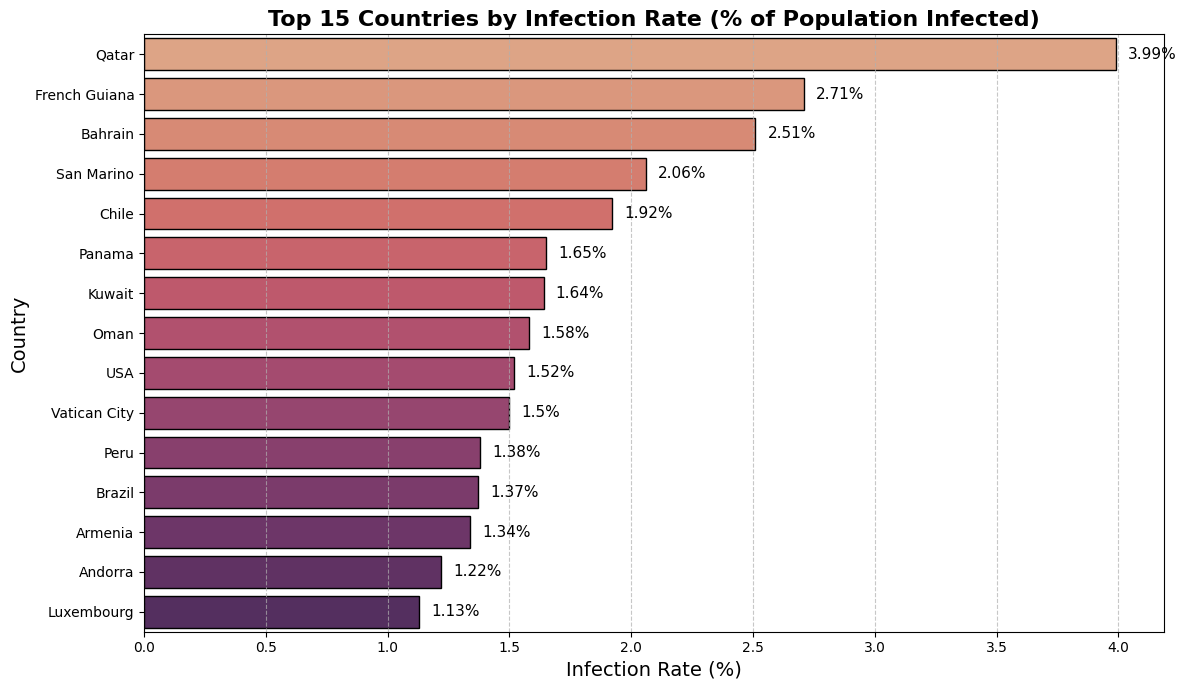

In [92]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=infection_pd, 
    x="infection_rate", 
    y="Country/Region", 
    palette="flare", 
    edgecolor='black'
)

# Formatting the chart
plt.title("Top 15 Countries by Infection Rate (% of Population Infected)", fontsize=16, fontweight='bold')
plt.xlabel("Infection Rate (%)", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentage labels to the end of each bar
for index, value in enumerate(infection_pd["infection_rate"]):
    plt.text(value + 0.05, index, f"{value}%", va='center', fontsize=11)

plt.tight_layout()
plt.show()

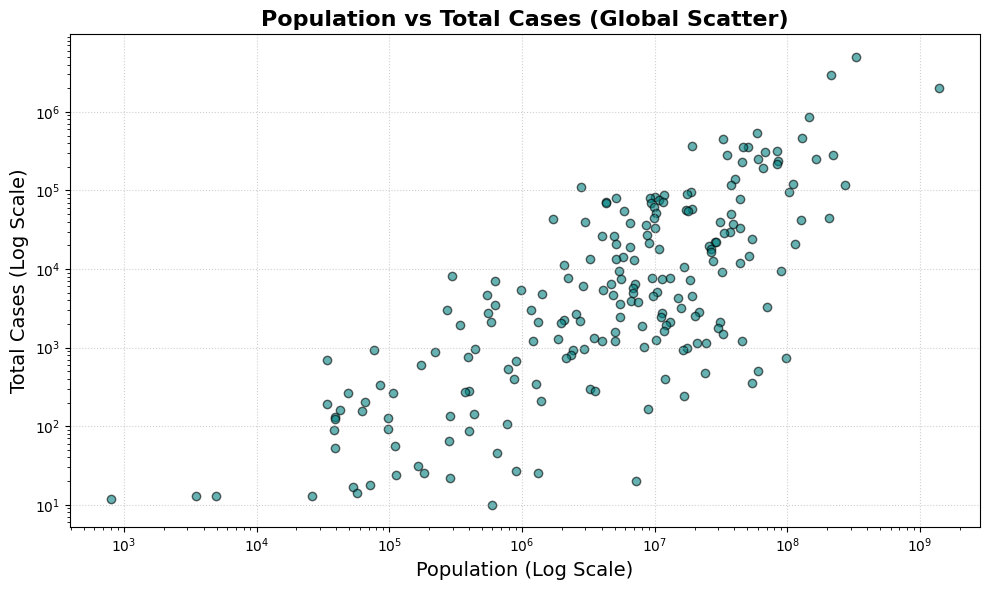

In [93]:
# Looking at how population size overall correlates with total cases
scatter_pd = infection_df.select("Population", "TotalCases", "Country/Region").dropna().toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_pd["Population"], scatter_pd["TotalCases"], color='teal', alpha=0.6, edgecolor='black')
plt.title("Population vs Total Cases (Global Scatter)", fontsize=16, fontweight='bold')
plt.xlabel("Population (Log Scale)", fontsize=14)
plt.ylabel("Total Cases (Log Scale)", fontsize=14)
plt.xscale('log') # Log scale helps because populations vary massively (e.g., Vatican vs India)
plt.yscale('log')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Geographic Analysis

#### USA State-wise Case Distribution

In [94]:
from pyspark.sql.functions import countDistinct

In [95]:
# Converting the 'Date' string  to an actual DateType so we can find the maximum/latest date
df_usa_county = df_usa_county.withColumn("Date_Parsed", to_date(col("Date"), "M/d/yy"))
latest_date_usa = df_usa_county.select(_max("Date_Parsed")).collect()[0][0]

In [96]:
print(f"Filtering data for the latest date: {latest_date_usa}")

Filtering data for the latest date: 2020-07-27


In [97]:
# Filtering for the latest date, then Group by 'Province_State'
state_distribution = (df_usa_county
    .filter(col("Date_Parsed") == latest_date_usa)
    .groupBy("Province_State")
    .agg(
        countDistinct("Admin2").alias("Number of Counties"),
        _sum("Confirmed").alias("Total Confirmed Cases")
    )
    .orderBy(col("Total Confirmed Cases").desc()))

In [98]:
# Showing the output table (Top 20 States)
print("USA State-wise Case Distribution & County Count:")
state_distribution.show(20, truncate=False)

USA State-wise Case Distribution & County Count:
+--------------+------------------+---------------------+
|Province_State|Number of Counties|Total Confirmed Cases|
+--------------+------------------+---------------------+
|California    |60                |458121               |
|Florida       |69                |432747               |
|New York      |64                |412344               |
|Texas         |256               |400336               |
|New Jersey    |23                |179812               |
|Illinois      |104               |173894               |
|Georgia       |161               |170843               |
|Arizona       |17                |163827               |
|Massachusetts |17                |115926               |
|North Carolina|102               |114916               |
|Pennsylvania  |69                |112995               |
|Louisiana     |66                |109917               |
|Tennessee     |97                |96489                |
|Michigan      |87     

In [99]:
state_pd = state_distribution.limit(20).toPandas()

In [100]:
state_pd

,Province_State,Number of Counties,Total Confirmed Cases
0,California,60,458121
1,Florida,69,432747
2,New York,64,412344
3,Texas,256,400336
4,New Jersey,23,179812
5,Illinois,104,173894
6,Georgia,161,170843
7,Arizona,17,163827
8,Massachusetts,17,115926
9,North Carolina,102,114916


C:\Users\aman3133\AppData\Local\Temp\ipykernel_4408\1584309194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


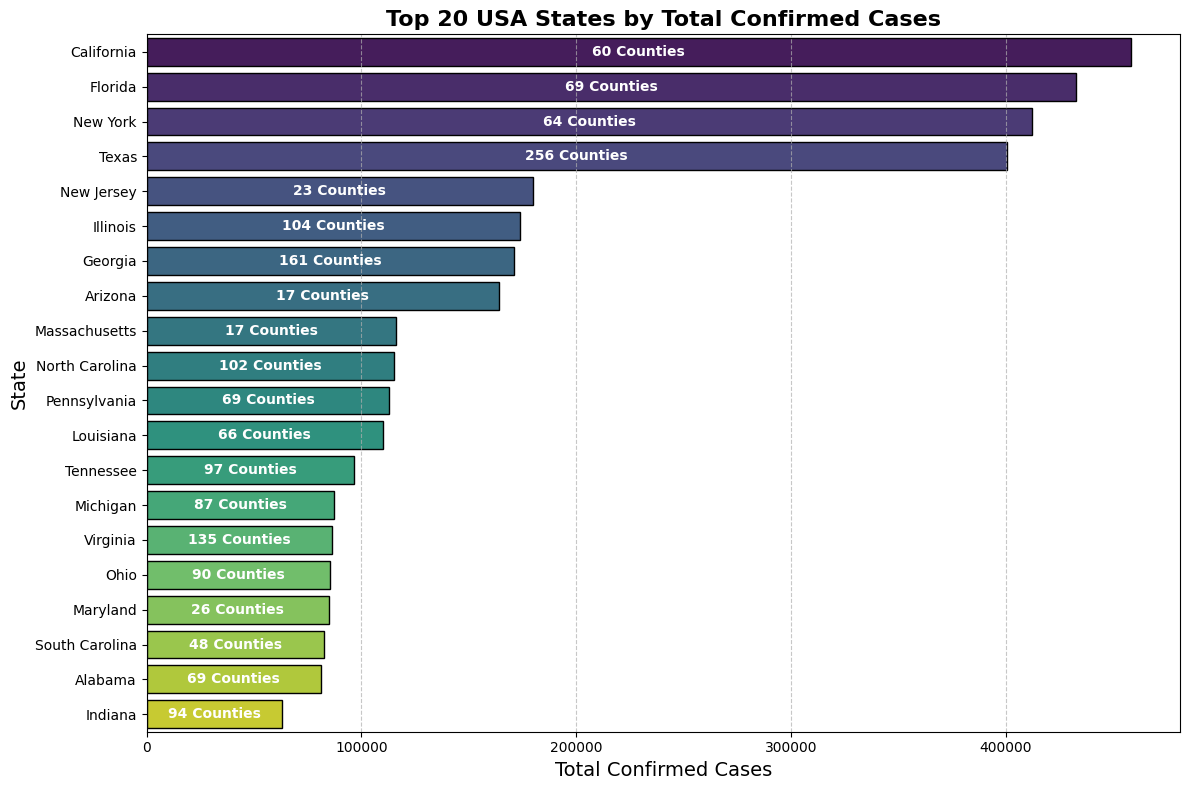

In [101]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_pd, 
    x="Total Confirmed Cases", 
    y="Province_State", 
    palette="viridis",
    edgecolor="black"
)

# Formatting the chart
plt.title("Top 20 USA States by Total Confirmed Cases", fontsize=16, fontweight='bold')
plt.xlabel("Total Confirmed Cases", fontsize=14)
plt.ylabel("State", fontsize=14)
plt.ticklabel_format(style='plain', axis='x') # Disable scientific notation
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the number of counties as a text label on the bars to satisfy the specific task requirement
for index, row in state_pd.iterrows():
    plt.text(
        row["Total Confirmed Cases"] * 0.5, # Position text in the middle of the bar
        index, 
        f'{row["Number of Counties"]} Counties', 
        color='white', 
        ha="center", 
        va="center", 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

#### Latitude-Longitude Based Case Clusters

In [102]:
import plotly.express as px
# import plotly.io as pio
# pio.renderers.default = "browser"

In [103]:
# Finding the latest date in the dataset to get the most recent cumulative case counts
latest_date_geo = df_covid_clean.select(_max("Date")).collect()[0][0]
print(f"Filtering geo data for the latest date: {latest_date_geo}")

Filtering geo data for the latest date: 2020-07-27


In [104]:
# Filtering for the latest date and select the required columns
geo_clusters = (df_covid_clean
    .filter(col("Date") == latest_date_geo)
    .select("Country/Region", "Province/State", "Lat", "Long", "Confirmed")
    .filter(col("Confirmed") > 0) # Removing locations with 0 cases to keep the map clean
)

In [105]:
# Showing the output dataset
print("Latitude-Longitude Based Case Clusters (Sample):")
geo_clusters.show(10)

Latitude-Longitude Based Case Clusters (Sample):
+-------------------+--------------------+--------+---------+---------+
|     Country/Region|      Province/State|     Lat|     Long|Confirmed|
+-------------------+--------------------+--------+---------+---------+
|        Afghanistan|             Unknown|33.93911|67.709953|    36263|
|            Albania|             Unknown| 41.1533|  20.1683|     4880|
|            Algeria|             Unknown| 28.0339|   1.6596|    27973|
|            Andorra|             Unknown| 42.5063|   1.5218|      907|
|             Angola|             Unknown|-11.2027|  17.8739|      950|
|Antigua and Barbuda|             Unknown| 17.0608| -61.7964|       86|
|          Argentina|             Unknown|-38.4161| -63.6167|   167416|
|            Armenia|             Unknown| 40.0691|  45.0382|    37390|
|          Australia|Australian Capita...|-35.4735| 149.0124|      113|
|          Australia|     New South Wales|-33.8688| 151.2093|     3699|
+--------------

In [106]:
geo_pd = geo_clusters.toPandas()

In [107]:
# Create the interactive geographical scatter plot
fig = px.scatter_geo(
    geo_pd,
    lat="Lat",
    lon="Long",
    color="Confirmed",                 # Color of the bubbles based on Confirmed cases
    size="Confirmed",                  # Size of the bubbles based on Confirmed cases
    hover_name="Country/Region",       # Showing Country name on hover
    hover_data=["Province/State"],     # Showing Province/State on hover as extra info
    projection="natural earth",        # Used a nice curved map projection
    title="Global COVID-19 Case Clusters based on Latitude & Longitude",
    color_continuous_scale="Oryel",    # A nice Orange/Yellow/Red scale for severity
    size_max=50                        # Maximum bubble size so massive countries don't cover the whole map
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="Black",
        projection_type='equirectangular'
    )
)

# Showing the interactive map
fig.show()